In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("spam (1).csv",encoding = "Latin_1")

In [4]:
print(df.head(5))

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [5]:
df1 = df[["v1","v2"]]

In [6]:
df1.columns = ["Label","Text"]

In [7]:
df1["Label"] = df1["Label"].map({"ham":0,"spam":1})

In [8]:
df1.head()

,Label,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print(df1.tail(5))

      Label                                               Text
5567      1  This is the 2nd time we have tried 2 contact u...
5568      0              Will Ì_ b going to esplanade fr home?
5569      0  Pity, * was in mood for that. So...any other s...
5570      0  The guy did some bitching but I acted like i'd...
5571      0                         Rofl. Its true to its name


In [10]:
print(df1.isnull())

      Label   Text
0     False  False
1     False  False
2     False  False
3     False  False
4     False  False
...     ...    ...
5567  False  False
5568  False  False
5569  False  False
5570  False  False
5571  False  False

[5572 rows x 2 columns]


In [11]:
print(df1.isnull().sum())

Label    0
Text     0
dtype: int64


In [12]:
x = df1["Text"]
y = df1["Label"]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [16]:
tokens = Tokenizer(num_words=5000)

In [17]:
print(tokens)

In [18]:
tokens.fit_on_texts(x_train)

In [19]:
x_train_new = tokens.texts_to_sequences(x_train)

In [20]:
x_test_new = tokens.texts_to_sequences(x_test)

In [21]:
print(x_train_new[0])

[38, 30, 8, 5, 273, 1989, 81, 116, 26, 11, 1656, 322, 10, 53, 18, 299, 30, 349, 1990]


In [22]:
print(x_test_new[0])

[1366, 1578, 1432, 19, 19, 19, 38, 118, 1650, 19, 738, 4, 449, 3023, 35, 1285]


In [23]:
len(x_train_new)

4457

In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [25]:
max_length = 50
x_train_padding = pad_sequences(x_train_new, maxlen = max_length)

In [26]:
x_test_padding = pad_sequences(x_test_new, maxlen = max_length)

In [27]:
print(x_train_padding[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0   38   30    8    5  273 1989   81  116   26   11 1656
  322   10   53   18  299   30  349 1990]


In [28]:
print(x_test_padding[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0 1366 1578 1432   19   19   19   38  118
 1650   19  738    4  449 3023   35 1285]


In [29]:
from tensorflow.keras.models import Sequential

In [30]:
from tensorflow.keras.layers import Dense ,SimpleRNN,Embedding

In [31]:
model = Sequential()
model.add(Embedding(
       input_dim=5000,
       output_dim=32,
))

In [32]:
model.add(SimpleRNN(32))
model.add(Dense(1,activation="sigmoid"))

In [33]:
model.compile(loss="binary_crossentropy",
              optimizer = "adam",
              metrics = ["accuracy"])

In [62]:
history = model.fit(x_train_padding,y_train,epochs=10,validation_split = 0.2,batch_size=32)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 7.7904e-04 - val_accuracy: 0.9832 - val_loss: 0.0823
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 5.9370e-04 - val_accuracy: 0.9832 - val_loss: 0.0937
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 4.7723e-04 - val_accuracy: 0.9832 - val_loss: 0.0968
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 3.9188e-04 - val_accuracy: 0.9821 - val_loss: 0.0983
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 3.2720e-04 - val_accuracy: 0.9809 - val_loss: 0.1043
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 2.7910e-04 - val_accuracy: 0.9809 - val_loss: 0.1077
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 2.4105e-04 - val_accuracy: 0.9809 - val_loss: 0.1093
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.00

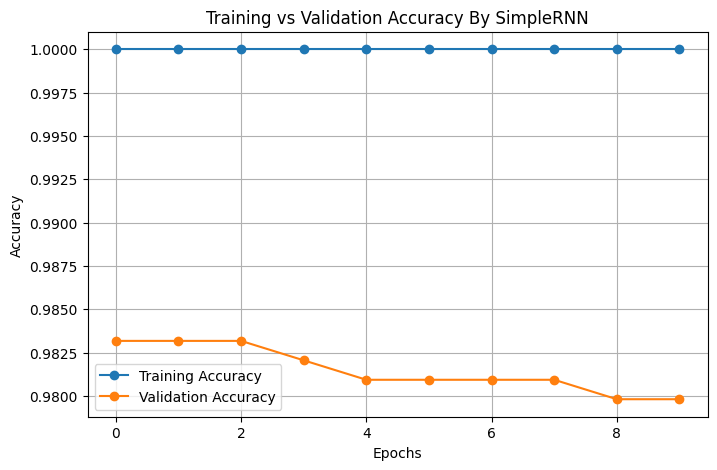

In [96]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],marker = "o", label='Training Accuracy')
plt.plot(history.history['val_accuracy'],marker = "o", label='Validation Accuracy')

plt.title('Training vs Validation Accuracy By SimpleRNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

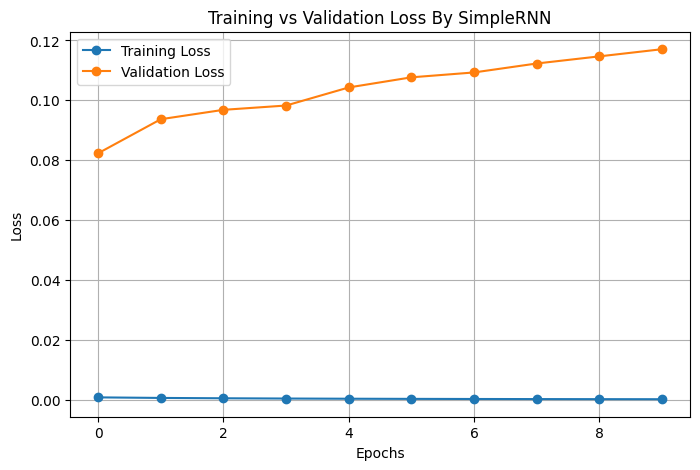

In [97]:
# Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],marker = "o", label='Training Loss')
plt.plot(history.history['val_loss'],marker = "o", label='Validation Loss')

plt.title('Training vs Validation Loss By SimpleRNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [98]:
model.evaluate(x_test_padding,y_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9803 - loss: 0.1259


[0.1259303241968155, 0.9802690744400024]

In [65]:
from sklearn.metrics import accuracy_score, recall_score,precision_score, f1_score, confusion_matrix, classification_report

In [66]:
y_pred_prob = model.predict(x_test_padding)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [67]:
print(y_pred_prob)

[[9.9928564e-01]
 [1.2680645e-04]
 [9.2735434e-01]
 ...
 [8.3988911e-05]
 [7.1514020e-05]
 [6.0067469e-01]]


In [68]:
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

In [69]:
print(y_pred)

[1 0 1 ... 0 0 1]


In [70]:
accuracy = accuracy_score(y_test,y_pred)

In [71]:
print("Accuracy:",accuracy)

Accuracy: 0.9802690582959641


In [72]:
precision = precision_score(y_test,y_pred)

In [73]:
print("Precision:",precision)

Precision: 0.9848484848484849


In [74]:
recall = recall_score(y_test,y_pred)

In [75]:
print("Recall:",recall)

Recall: 0.8666666666666667


In [76]:
f1 = f1_score(y_test,y_pred)

In [77]:
print("F1:",f1)

F1: 0.9219858156028369


In [78]:
cm = confusion_matrix(y_test,y_pred)

In [79]:
print("cm",cm)

cm [[963   2]
 [ 20 130]]


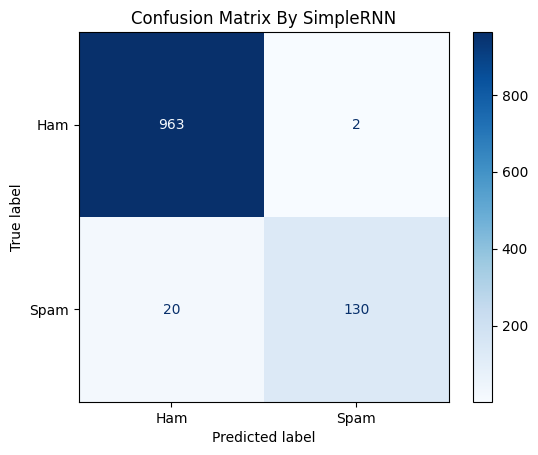

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix By SimpleRNN')
plt.show()

In [80]:
cr = classification_report(y_test,y_pred)

In [81]:
print("cr",cr)

cr               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [82]:
user_input = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]

In [83]:
user_input_token = tokens.texts_to_sequences(user_input)

In [84]:
print(user_input_token)

[[49, 435, 8, 19, 4, 734, 777, 2, 181, 1827, 1130, 612, 1828, 2217, 253, 2897, 69, 1827, 2, 1829, 2, 316, 435, 556, 932, 71, 403, 174, 653, 397, 2898]]


In [85]:
user_padding = pad_sequences(user_input_token,maxlen=max_length)

In [86]:
print(user_padding)

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0   49  435    8   19    4  734  777    2  181
  1827 1130  612 1828 2217  253 2897   69 1827    2 1829    2  316  435
   556  932   71  403  174  653  397 2898]]


In [87]:
prediction = model.predict(user_padding)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [88]:
print(prediction)

[[0.9998838]]


In [89]:
if prediction[0][0]>0.5:
  print("spam")
else:
  print("ham")

spam
